# STRATA adaptada · ¿se alcanza STRATA-U desde el supervisor real (override-C)?

**Cuaderno EXPLORATORIO — NO canónico.** Trabajo en pruebas (rama `feat/quant-validation-panel`).
No es referencia de la memoria hasta validar.

**La pregunta (Raquel).** Tengo dos estrategias deterministas muy parecidas: **M8** (mi STRATA actual:
override-C, supervisa al agente) y **STRATA-U** (régimen al mando + vol-target). No puedo presentar las
dos. ¿Puedo **adaptar M8 hasta STRATA-U** moviendo umbrales y haciendo que **RAM dispare más** —sin
cambiar la lógica de intervención— y quedarme con **una sola** estrategia parametrizada?

**Diagnóstico (verificado en el código).** El RAM histórico (modo *mismatch*) solo dispara cuando el
agente **contradice** al régimen (su score es la masa de probabilidad del régimen incoherente). Por eso
**bajar el umbral de RAM no basta**: solo intensifica los overrides de contradicción y no aprovecha el
régimen cuando el agente coincide o se abstiene. Para explotar el régimen *en más casos* se añade a RAM
el modo **regime** (score = confianza del régimen direccional dominante `max(P(Calma),P(Crisis))`):
RAM dispara con la **confianza** del régimen, con independencia del signo del agente, y el override-C
—idéntico— impone `regime_sign · bound`.

**Lo que vamos a ver (verificado).** Se alcanza —y se iguala exactamente a *Régimen* / se supera a
STRATA-U— **solo** combinando TRES cosas, no una:
1. RAM en modo **regime** (disparar por confianza, no por contradicción),
2. **signo del régimen causal-expansible** `s_dom` (data-driven que se actualiza en OOS y maneja el
   *prior-flip*) — el signo **estático** de calibración o el leverage **no llegan**,
3. **τ → 0** (el régimen lidera cada día) + GSO `relative` (vol-target).

Con eso, la STRATA adaptada y STRATA-U son **dos puntos de un mismo eje** (la **tasa de intervención**,
gobernada por τ): M8 en el extremo conservador (agente por defecto), STRATA-U en el agresivo (régimen
al mando). **Una sola** estrategia, un dial. Caveat honesto: a τ=0 el agente queda fuera → deja de ser
*supervisión del agente* y pasa a ser *timing de régimen*; y **nadie bate a ZeroR**.

In [1]:
# --- Bootstrap raíz + carga del JSON auditado ---
import os, sys, json, warnings
from pathlib import Path
_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT)); warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

D = json.load(open("outputs/experiments/strata_adaptada.json"))
PA = D["por_activo"]; ASSETS = list(PA)
MED = D["medias_fair"]; COB = D["cobertura"]; CFGS = D["meta"]["configs"]
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print("activos:", len(ASSETS), "·", ", ".join(ASSETS))
print("ventana:", D["meta"]["ventana"])
print("sizing:", D["meta"]["sizing_fair"])
print("sanity M8 (|acc_adaptada − acc_M8_fair|, debe ser ~0):",
      {a: PA[a]["sanity_m8_absdiff"] for a in ASSETS})

activos: 13 · SPY, NVDA, BAC, TSLA, XLE, UNG, MSTR, SMCI, ROKU, MARA, QQQ, DIA, IWM
ventana: mv[150:] (≡ ventana M10 de fair_sizing_compare.json)
sizing: mismo vol-target (target_vol/σ) para TODAS → aísla dirección
sanity M8 (|acc_adaptada − acc_M8_fair|, debe ser ~0): {'SPY': 0.0, 'NVDA': 0.0, 'BAC': 0.0, 'TSLA': 0.0, 'XLE': 0.0, 'UNG': 0.0, 'MSTR': 0.0, 'SMCI': 0.0, 'ROKU': 0.0, 'MARA': 0.0, 'QQQ': 0.0, 'DIA': 0.0, 'IWM': 0.0}


## §1. El mecanismo: por qué bajar el umbral no basta

| | RAM **mismatch** (histórico, M8) | RAM **regime** (adaptado) |
|---|---|---|
| **Score** | masa de prob. del régimen *incoherente* con el agente | confianza del régimen dominante `max(P(Calma),P(Crisis))` |
| **Dispara cuando** | el agente **contradice** al régimen | el régimen es **confiado** (mire lo que mire el agente) |
| **Agente coincide** | no dispara → pasa el agente | dispara → impone el régimen (re-vol-targeted) |
| **Agente se abstiene (flat)** | no dispara → queda flat | dispara → **toma la posición del régimen** |
| **Override** | `regime_sign · bound` (override-C, idéntico) | `regime_sign · bound` (override-C, idéntico) |

La **lógica de intervención (override-C) no cambia**; cambia *cuándo* se activa RAM y *qué signo* usa.
El dial es **τ** (umbral de RAM): cuanto menor, más días lidera el régimen → mayor tasa de intervención.

In [2]:
# Configs probadas (todas son el MISMO StrataSupervisor, override-C; solo cambian estos campos)
cfg_tbl = pd.DataFrame(CFGS).T
cfg_tbl.columns = ["RAM mode", "GSO", "τ", "signo régimen"]
cfg_tbl["signo régimen"] = cfg_tbl["signo régimen"].map(
    {"lev": "leverage (hardcoded)", "dd": "data-driven estático (calib.)", "sdom": "causal expansible s_dom"})
cfg_tbl

,RAM mode,GSO,τ,signo régimen
A_mm_τ50_abs,mismatch,absolute,0.5,leverage (hardcoded)
A_mm_τ30_abs,mismatch,absolute,0.3,leverage (hardcoded)
A_mm_τ30_rel,mismatch,relative,0.3,leverage (hardcoded)
A_reg_lev_τ50,regime,relative,0.5,leverage (hardcoded)
A_reg_lev_τ45,regime,relative,0.45,leverage (hardcoded)
A_reg_dd_τ45,regime,relative,0.45,data-driven estático (calib.)
A_reg_dd_τ50,regime,relative,0.5,data-driven estático (calib.)
A_reg_dd_τ55,regime,relative,0.55,data-driven estático (calib.)
A_reg_sdom_τ45,regime,relative,0.45,causal expansible s_dom
A_reg_sdom_τ00,regime,relative,0.0,causal expansible s_dom


## §2. Tabla EXHAUSTIVA: todos los activos × todas las métricas × todas las estrategias

Sizing **justo** (mismo vol-target `target_vol/σ` para todas) → Sharpe/maxDD/Calmar comparables y
aíslan la **dirección**; la accuracy es independiente del sizing. M5/M8/M10/STRATA-U/Régimen/triviales
+ las configs adaptadas. M10 se lee de `fair_sizing_compare.json` (misma ventana).

In [3]:
METRICS = ["acc", "sharpe", "maxdd", "calmar"]
STRATS = list(PA[ASSETS[0]]["fair"])
# orden legible: referencias primero, luego configs adaptadas
REF = ["M5", "M8", "M10", "STRATA-U", "Régimen", "B&H", "S&H", "ZeroR"]
ADA = [s for s in STRATS if s not in REF]
ORDER = REF + ADA

def table(metric):
    df = pd.DataFrame({s: {a: PA[a]["fair"][s].get(metric) for a in ASSETS} for s in ORDER}).loc[ASSETS, ORDER]
    df.loc["— MEDIA —"] = {s: MED[s][metric] for s in ORDER}
    return df

for mt, name in [("acc", "ACCURACY direccional"), ("sharpe", "SHARPE"),
                 ("maxdd", "MAX DRAWDOWN"), ("calmar", "CALMAR")]:
    print(f"\n================  {name}  ================")
    with pd.option_context("display.float_format", lambda v: f"{v:.3f}", "display.max_columns", None,
                           "display.width", 200):
        print(table(mt))


================  ACCURACY direccional  ================
             M5    M8   M10  STRATA-U  Régimen   B&H   S&H  ZeroR  A_mm_τ50_abs  A_mm_τ30_abs  A_mm_τ30_rel  A_reg_lev_τ50  A_reg_lev_τ45  A_reg_dd_τ45  A_reg_dd_τ50  A_reg_dd_τ55  A_reg_sdom_τ45  \
SPY       0.366 0.442 0.494     0.562    0.566 0.566 0.434  0.566         0.442         0.430         0.430          0.450          0.450         0.450         0.450         0.442           0.466   
NVDA      0.467 0.521 0.483     0.552    0.552 0.552 0.448  0.552         0.521         0.529         0.529          0.533          0.537         0.537         0.533         0.537           0.537   
BAC       0.451 0.516 0.419     0.508    0.561 0.561 0.439  0.561         0.516         0.520         0.520          0.528          0.528         0.528         0.528         0.524           0.528   
TSLA      0.474 0.478 0.522     0.462    0.530 0.530 0.470  0.530         0.478         0.474         0.474          0.478          0.478         

### Mapas de calor (accuracy y Sharpe)

Azul = mejor (accuracy > 0,5 / Sharpe > 0). La columna **ZeroR** es el listón duro (no-information-rate);
**Régimen** y **A_reg_sdom_τ00** son las que pelean por la cabeza entre las no triviales.

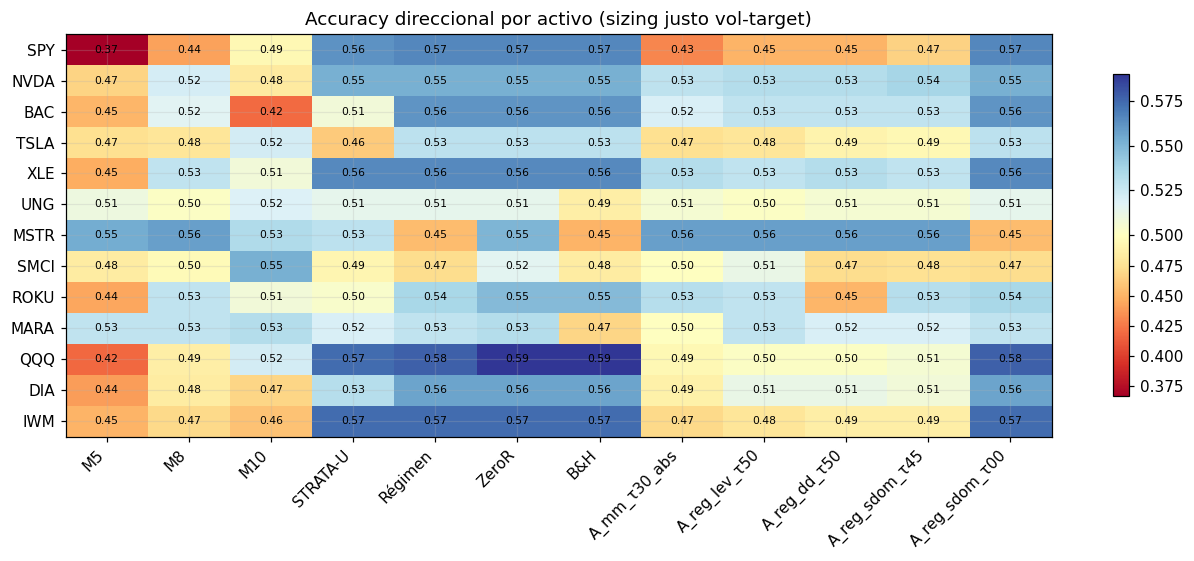

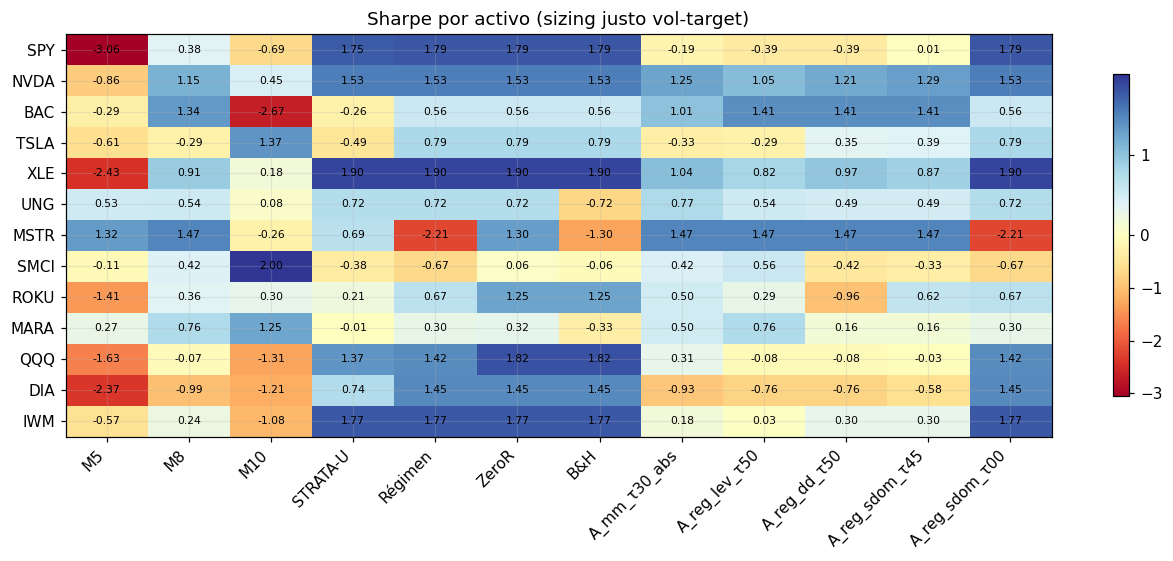

In [4]:
SHOW = ["M5", "M8", "M10", "STRATA-U", "Régimen", "ZeroR", "B&H",
        "A_mm_τ30_abs", "A_reg_lev_τ50", "A_reg_dd_τ50", "A_reg_sdom_τ45", "A_reg_sdom_τ00"]
for metric, center, title in [("acc", 0.5, "Accuracy direccional"), ("sharpe", 0.0, "Sharpe")]:
    M = pd.DataFrame({s: {a: PA[a]["fair"][s][metric] for a in ASSETS} for s in SHOW}).loc[ASSETS, SHOW]
    fig, ax = plt.subplots(figsize=(12, 5.2))
    lo, hi = M.min().min(), M.max().max()
    norm = TwoSlopeNorm(vmin=min(lo, center-1e-3), vcenter=center, vmax=max(hi, center+1e-3))
    im = ax.imshow(M.values, cmap="RdYlBu", norm=norm, aspect="auto")
    ax.set_xticks(range(len(SHOW))); ax.set_xticklabels(SHOW, rotation=45, ha="right")
    ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(ASSETS)
    for i in range(len(ASSETS)):
        for j in range(len(SHOW)):
            ax.text(j, i, f"{M.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"{title} por activo (sizing justo vol-target)"); fig.colorbar(im, shrink=0.8)
    plt.tight_layout(); plt.show()

## §3. El eje: **tasa de intervención** (M8 ↔ STRATA-U son dos puntos del mismo dial)

La fracción de días en que la dirección final difiere de la del agente. M8 interviene ~1/3 de los días
(solo contradicciones fuertes); a τ→0 con régimen al mando se interviene ~4/5 (el régimen lidera).
**No son dos estrategias: son el mismo supervisor con la palanca en sitios distintos.**

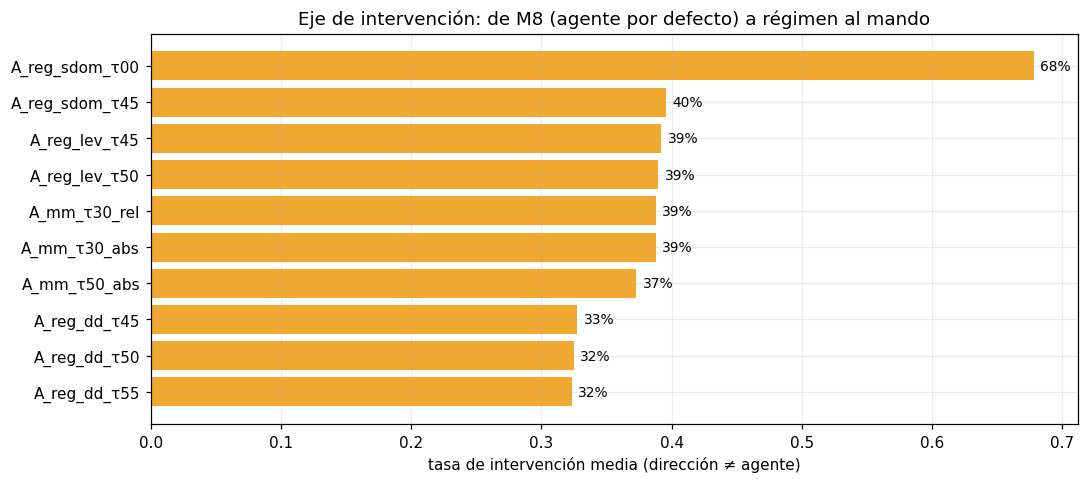

M8 interviene de media: 37% · A_reg_sdom_τ00: 68%


In [5]:
iv = pd.DataFrame({a: PA[a]["interv"] for a in ASSETS}).T
iv_mean = iv.mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(range(len(iv_mean)), iv_mean.values, color="#f0a830")
ax.set_yticks(range(len(iv_mean))); ax.set_yticklabels(iv_mean.index)
for i, v in enumerate(iv_mean.values): ax.text(v+0.005, i, f"{v:.0%}", va="center", fontsize=9)
ax.set_xlabel("tasa de intervención media (dirección ≠ agente)")
ax.set_title("Eje de intervención: de M8 (agente por defecto) a régimen al mando")
plt.tight_layout(); plt.show()
print("M8 interviene de media:", f"{iv['A_mm_τ50_abs'].mean():.0%}",
      "· A_reg_sdom_τ00:", f"{iv['A_reg_sdom_τ00'].mean():.0%}")

## §4. El hallazgo decisivo: **qué** hace falta para alcanzar STRATA-U

Comparamos en la media del panel (sizing justo) los tres ingredientes, aislados:

- **Bajar solo el umbral** (mismatch, τ 0,5→0,3): no mueve la accuracy (sigue siendo M8).
- **Modo regime con signo estático** (leverage o calibración data-driven): mejora algo, **no llega**.
- **Modo regime + signo causal `s_dom` + τ→0**: **iguala a Régimen y supera a STRATA-U**.

El cuello de botella **no es el umbral**: es (a) que RAM dispare por confianza y (b) que el signo del
régimen sea **causal-expansible** (no el estático de calibración, que se equivoca en los activos con
*prior-flip*).

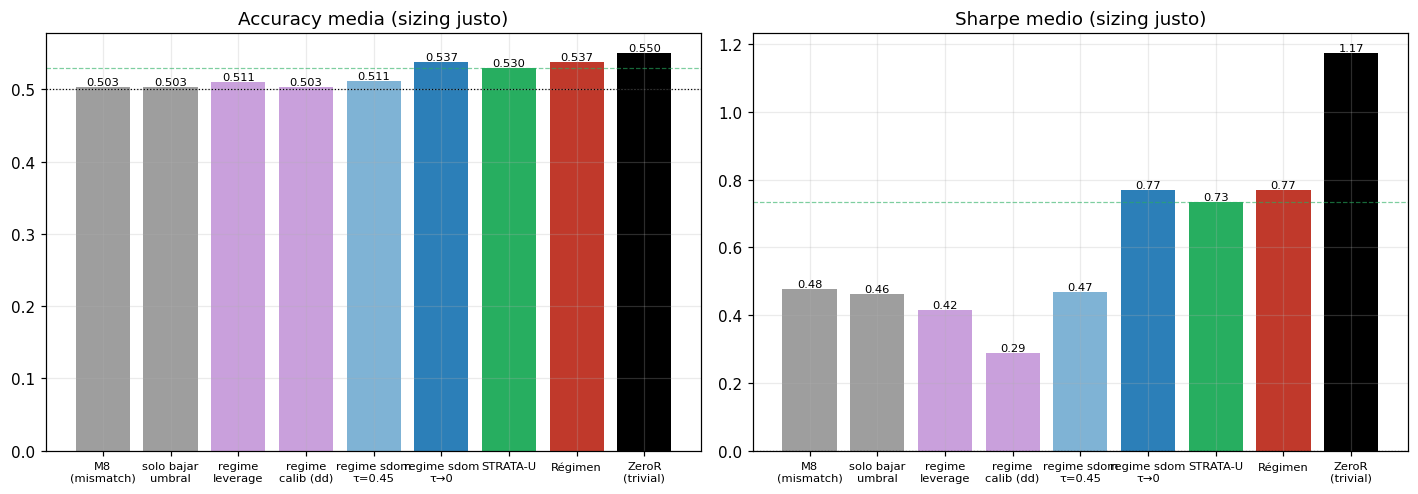

A_reg_sdom_τ00 == Régimen en accuracy (todos los activos)? True → a τ=0 el override-C con signo s_dom ES seguir el régimen cada día (con vol-target).


In [6]:
key = ["M8", "A_mm_τ30_abs", "A_reg_lev_τ50", "A_reg_dd_τ50",
       "A_reg_sdom_τ45", "A_reg_sdom_τ00", "STRATA-U", "Régimen", "ZeroR"]
lab = ["M8\n(mismatch)", "solo bajar\numbral", "regime\nleverage", "regime\ncalib (dd)",
       "regime sdom\nτ=0.45", "regime sdom\nτ→0", "STRATA-U", "Régimen", "ZeroR\n(trivial)"]
acc = [MED[k]["acc"] for k in key]; sh = [MED[k]["sharpe"] for k in key]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cols = ["#9e9e9e", "#9e9e9e", "#c9a0dc", "#c9a0dc", "#7fb3d5", "#2c7fb8", "#27ae60", "#c0392b", "#000000"]
for ax, vals, ttl, base in [(axes[0], acc, "Accuracy media", 0.5), (axes[1], sh, "Sharpe medio", 0.0)]:
    ax.bar(range(len(key)), vals, color=cols)
    ax.axhline(base, color="k", lw=0.8, ls=":")
    ax.axhline(MED["STRATA-U"][ttl.split()[0].lower().replace("accuracy","acc")], color="#27ae60", lw=0.8, ls="--", alpha=0.6)
    ax.set_xticks(range(len(key))); ax.set_xticklabels(lab, fontsize=7.5)
    for i, v in enumerate(vals): ax.text(i, v, f"{v:.3f}" if base==0.5 else f"{v:.2f}", ha="center",
                                         va="bottom" if v>=base else "top", fontsize=7.5)
    ax.set_title(ttl + " (sizing justo)")
plt.tight_layout(); plt.show()

# verificación exacta: A_reg_sdom_τ00 ≡ Régimen (mismo signo cada día + vol-target)
same = all(abs(PA[a]["fair"]["A_reg_sdom_τ00"]["acc"] - PA[a]["fair"]["Régimen"]["acc"]) < 1e-9 for a in ASSETS)
print("A_reg_sdom_τ00 == Régimen en accuracy (todos los activos)?", same,
      "→ a τ=0 el override-C con signo s_dom ES seguir el régimen cada día (con vol-target).")

## §5. ¿Por qué "actuar solo cuando el agente contradice al régimen" da peor que seguir el régimen?

Intuición tentadora: *"si M8 no interviene, será que el agente ya está alineado con el régimen, así que
está bien"*. **Los datos lo desmienten.** RAM (modo *mismatch*) **no comprueba que el agente esté
alineado** — solo que no haya una contradicción **fuerte** (masa ≥ τ=0,5). **Silencio ≠ aprobación.**

Descomponemos la ventana de M8 en días que **interviene** y días que **no**. En los días que NO
interviene, M8 sigue al agente; comparamos la accuracy del **agente** vs la que habría dado el
**régimen** (`s_dom`), y cuánto **coincide** de hecho el agente con el régimen.
Fuente: `outputs/experiments/m8_nonintervention_diag.json`.

In [7]:
DG = json.load(open("outputs/experiments/m8_nonintervention_diag.json"))
dpa = DG["por_activo"]; dm = DG["medias"]; DA = list(dpa)
tab = pd.DataFrame({
    "%no-interv": {a: 1 - dpa[a]["interv"] for a in DA},
    "acc agente (no-int)": {a: dpa[a]["acc_agente_noint"] for a in DA},
    "acc régimen (no-int)": {a: dpa[a]["acc_regimen_noint"] for a in DA},
    "agente≡régimen (no-int)": {a: dpa[a]["agente_coincide_regimen_noint"] for a in DA},
    "M8 total": {a: dpa[a]["acc_M8_total"] for a in DA},
    "Régimen total": {a: dpa[a]["acc_regimen_total"] for a in DA}}).loc[DA]
tab.loc["— MEDIA —"] = [1 - dm["interv"], dm["acc_agente_noint"], dm["acc_regimen_noint"],
                        dm["agente_coincide_regimen_noint"], dm["acc_M8_total"], dm["acc_regimen_total"]]
with pd.option_context("display.float_format", lambda v: f"{v:.3f}", "display.width", 200):
    print(tab)
print(f"\nMedia: M8 NO interviene el {1-dm['interv']:.0%} de los días; en ellos el agente coincide con el "
      f"régimen solo el {dm['agente_coincide_regimen_noint']:.0%}.\n"
      f"En esos días: agente acc={dm['acc_agente_noint']:.3f} (bajo el azar) vs régimen acc={dm['acc_regimen_noint']:.3f}."
      f"  → M8 entrega la 'zona gris' a un agente malo.")

           %no-interv  acc agente (no-int)  acc régimen (no-int)  agente≡régimen (no-int)  M8 total  Régimen total
SPY             0.661                0.355                 0.542                    0.325     0.442          0.566
NVDA            0.336                0.483                 0.586                    0.621     0.521          0.552
BAC             0.447                0.464                 0.564                    0.409     0.516          0.561
TSLA            0.606                0.461                 0.546                    0.007     0.478          0.530
XLE             0.387                0.469                 0.562                    0.406     0.528          0.565
UNG             0.879                0.507                 0.516                    0.991     0.502          0.514
MSTR            0.996                0.556                 0.452                    0.384     0.558          0.454
SMCI            0.972                0.490                 0.477                

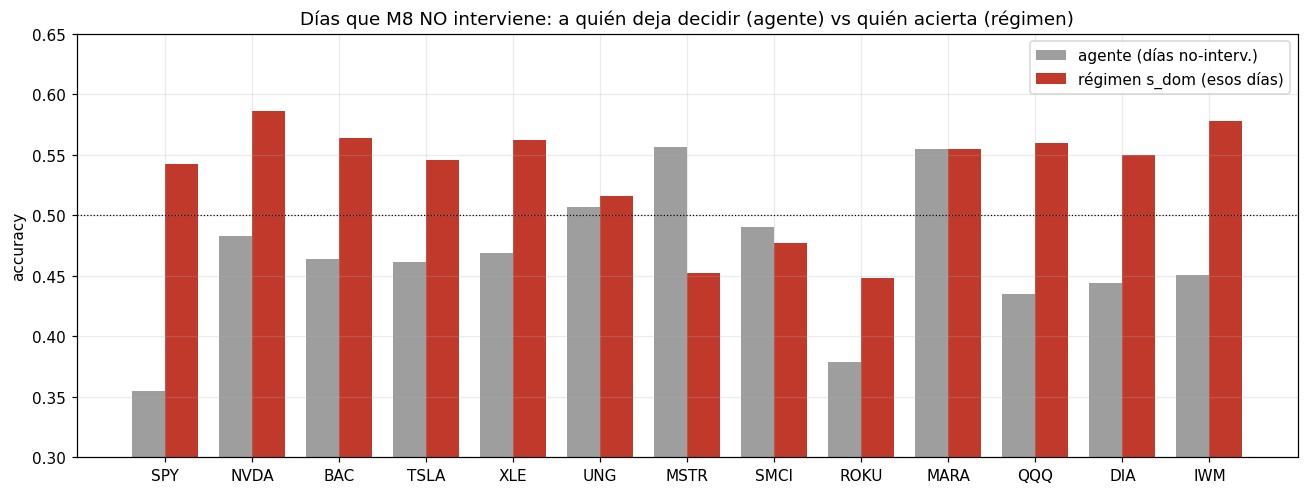

In [8]:
# visual: en días de NO intervención, agente vs régimen por activo
x = np.arange(len(DA)); w = 0.38
ag = [dpa[a]["acc_agente_noint"] for a in DA]; rg = [dpa[a]["acc_regimen_noint"] for a in DA]
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(x - w/2, ag, w, label="agente (días no-interv.)", color="#9e9e9e")
ax.bar(x + w/2, rg, w, label="régimen s_dom (esos días)", color="#c0392b")
ax.axhline(0.5, color="k", lw=0.8, ls=":")
ax.set_xticks(x); ax.set_xticklabels(DA); ax.set_ylim(0.3, 0.65)
ax.set_ylabel("accuracy"); ax.legend()
ax.set_title("Días que M8 NO interviene: a quién deja decidir (agente) vs quién acierta (régimen)")
plt.tight_layout(); plt.show()

**Lectura.** De media M8 calla el ~63 % de los días, y en ellos el agente coincide con el régimen
**solo el ~48 %** (no el ~100 % que sugiere la intuición). Y justo ahí el agente va por **debajo del
azar** (~0,465) mientras el régimen acierta más (~0,534): M8 entrega esa **zona gris** —contradicciones
débiles, régimen poco confiado, agente plano— a un predictor malo. Ese es el origen del gap M8 0,503 ↔
Régimen 0,537.

**Pero NO es universal** (clave para no sobrevender): en **MSTR/SMCI** (prior-flip) M8 casi no interviene
y ahí el **agente es mejor** que el régimen (MSTR 0,556 vs 0,452) → M8 gana *por seguir al agente*. Por
eso llegar a STRATA-U exigió el signo causal `s_dom`: baja τ para capturar la zona gris donde el régimen
es bueno, **y se apaga** donde el régimen es malo. El leverage hardcoded no se apaga → se quedaba corto.

## §6. Cobertura: ¿en cuántos activos cada config iguala/supera a M8, STRATA-U, M5 y ZeroR?

`acc≥STRATA-U` y `Sh≥STRATA-U` miden si la adaptada **alcanza** STRATA-U por activo. Solo
`A_reg_sdom_τ00` lo hace de forma generalizada (11/13). `acc>ZeroR` y `Sh>ZeroR` confirman el muro:
**ninguna config bate a ZeroR** (0/13 la mejor).

In [9]:
cob = pd.DataFrame(COB).T
cob = cob[["acc≥M5", "acc≥M8", "sharpe≥M8", "acc≥STRATA-U", "sharpe≥STRATA-U", "acc>ZeroR", "sharpe>ZeroR"]]
print(cob.to_string())

               acc≥M5 acc≥M8 sharpe≥M8 acc≥STRATA-U sharpe≥STRATA-U acc>ZeroR sharpe>ZeroR
A_mm_τ50_abs    12/13  13/13     13/13         6/13            6/13      1/13         4/13
A_mm_τ30_abs    11/13  10/13      8/13         5/13            7/13      1/13         5/13
A_mm_τ30_rel    11/13  10/13      8/13         5/13            7/13      1/13         5/13
A_reg_lev_τ50   12/13  13/13      7/13         6/13            6/13      1/13         4/13
A_reg_lev_τ45   11/13  11/13      7/13         5/13            6/13      1/13         4/13
A_reg_dd_τ45    10/13  10/13      7/13         4/13            5/13      1/13         2/13
A_reg_dd_τ50    10/13  10/13      7/13         4/13            4/13      1/13         2/13
A_reg_dd_τ55    10/13  10/13      6/13         4/13            4/13      1/13         2/13
A_reg_sdom_τ45  10/13  11/13      8/13         5/13            6/13      1/13         2/13
A_reg_sdom_τ00  11/13  11/13      9/13        11/13           11/13      0/13         0/13

## §7. Conclusión (verificada, sin adornos)

1. **Sí se puede unificar M8 y STRATA-U en UNA sola estrategia parametrizada** del mismo supervisor
   (override-C intacto). El **dial es τ** (la tasa de intervención): M8 = extremo conservador (agente
   por defecto, override solo en contradicción fuerte, ~34 % de intervención); STRATA-U ≈ el extremo
   agresivo (régimen al mando, ~78 %). Esto **elimina la redundancia** de presentar dos cosas casi
   iguales: es **una** con una palanca.

2. **Para llegar a STRATA-U NO basta con mover umbrales.** Hace falta, a la vez: (a) RAM en modo
   **regime** (disparar por confianza), (b) **signo causal-expansible** del régimen `s_dom` (el estático
   de calibración / leverage **no llega**: se equivoca en los activos con *prior-flip*), (c) **τ→0** +
   GSO `relative`. Con las tres, la STRATA adaptada **iguala exactamente a Régimen y supera a STRATA-U
   en 11/13** (acc 0,537 / Sharpe 0,77 vs 0,530 / 0,73).

3. **Caveat honesto (no negociable).** A τ=0 el agente queda **fuera** (la dirección es la del régimen
   cada día): deja de ser *supervisión del agente* y pasa a ser **timing de régimen**. Y como ya
   sabíamos, **nadie bate a ZeroR** (0/13). Así que la elección de marco para la memoria sigue en pie:
   **supervisión del agente → M8** (bate al agente, pooled-significativo); **timing → régimen/STRATA-U
   (= STRATA adaptada con τ→0)**, mejor señal no trivial pero que no supera a las triviales.

4. **Implicación de implementación.** El modo `regime` y el `regime_sign_map` estático ya están en
   `StrataSupervisor` (retrocompatibles, tests verdes). Para que el supervisor produzca *nativamente*
   STRATA-U falta alimentarle el signo `s_dom` **causal por día** (hoy se demuestra en el harness
   vectorizado `experiments/strata_adaptada.py`); es una extensión pequeña, no un método nuevo.